# EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

train = pd.read_csv("train.csv")
df = train.copy()

In [2]:
df.shape

(8693, 14)

In [3]:
for clmn in df.columns.tolist():
    print(clmn)

PassengerId
HomePlanet
CryoSleep
Cabin
Destination
Age
VIP
RoomService
FoodCourt
ShoppingMall
Spa
VRDeck
Name
Transported


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [5]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
for clmn in df.columns.tolist():
    print(f"{clmn}: {df[clmn].nunique()}")

PassengerId: 8693
HomePlanet: 3
CryoSleep: 2
Cabin: 6560
Destination: 3
Age: 80
VIP: 2
RoomService: 1273
FoodCourt: 1507
ShoppingMall: 1115
Spa: 1327
VRDeck: 1306
Name: 8473
Transported: 2


In [8]:
df_clean = df.copy()

In [9]:
df_clean.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# EDA Построение различных графиков

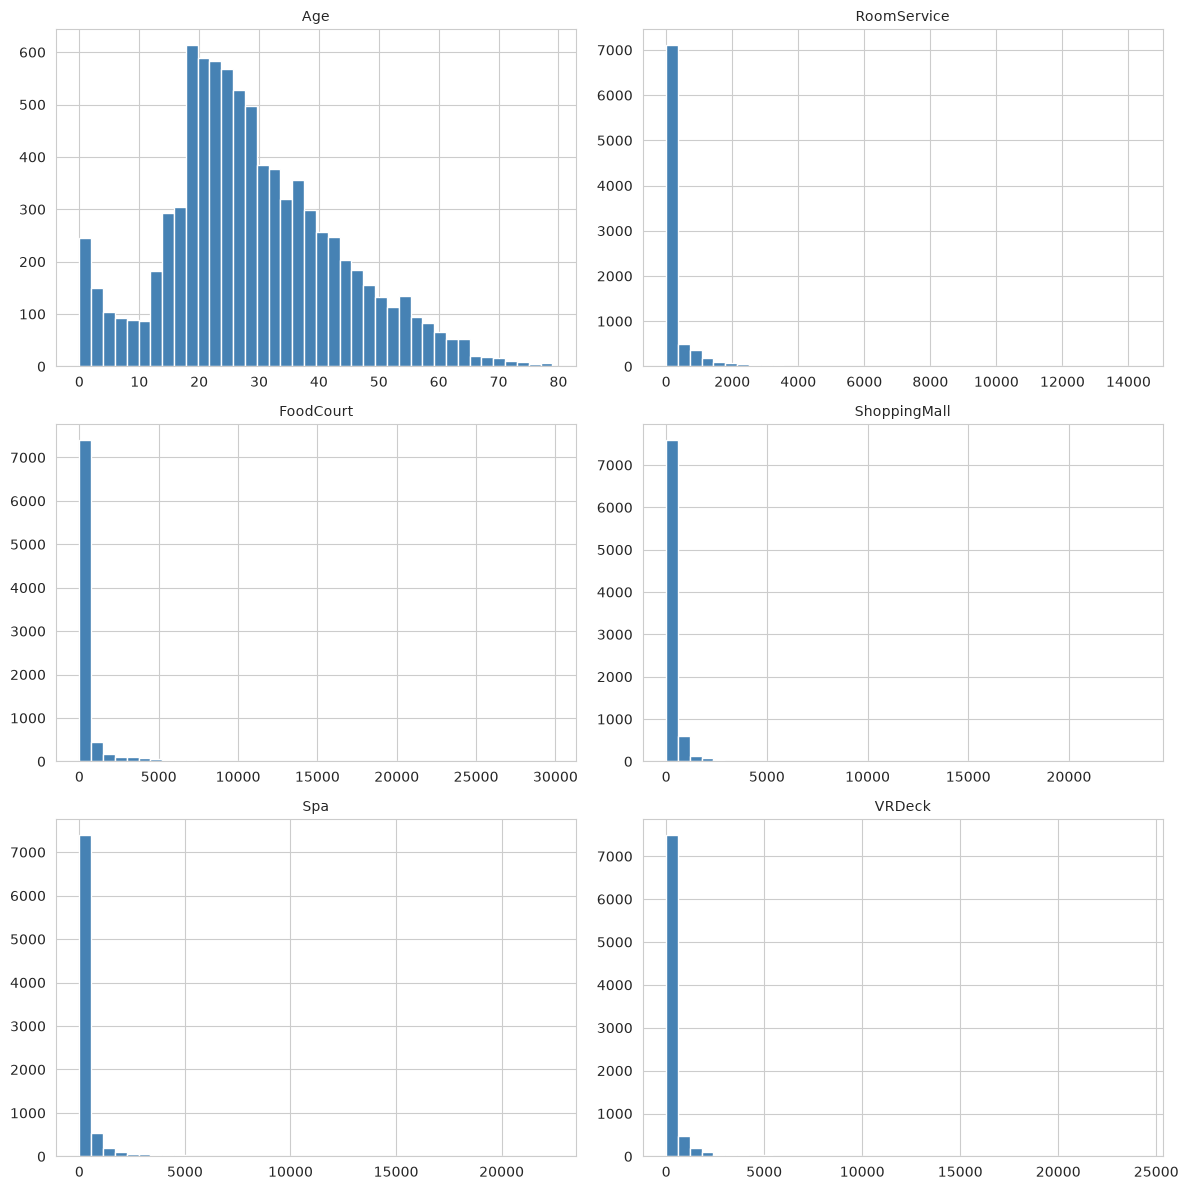

In [10]:
numeric_cols = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    df_clean[col].hist(
        bins=40,
        ax=axes[i],
        color='steelblue',
        edgecolor='white'
    )
    axes[i].set_title(col, fontsize=10)

for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

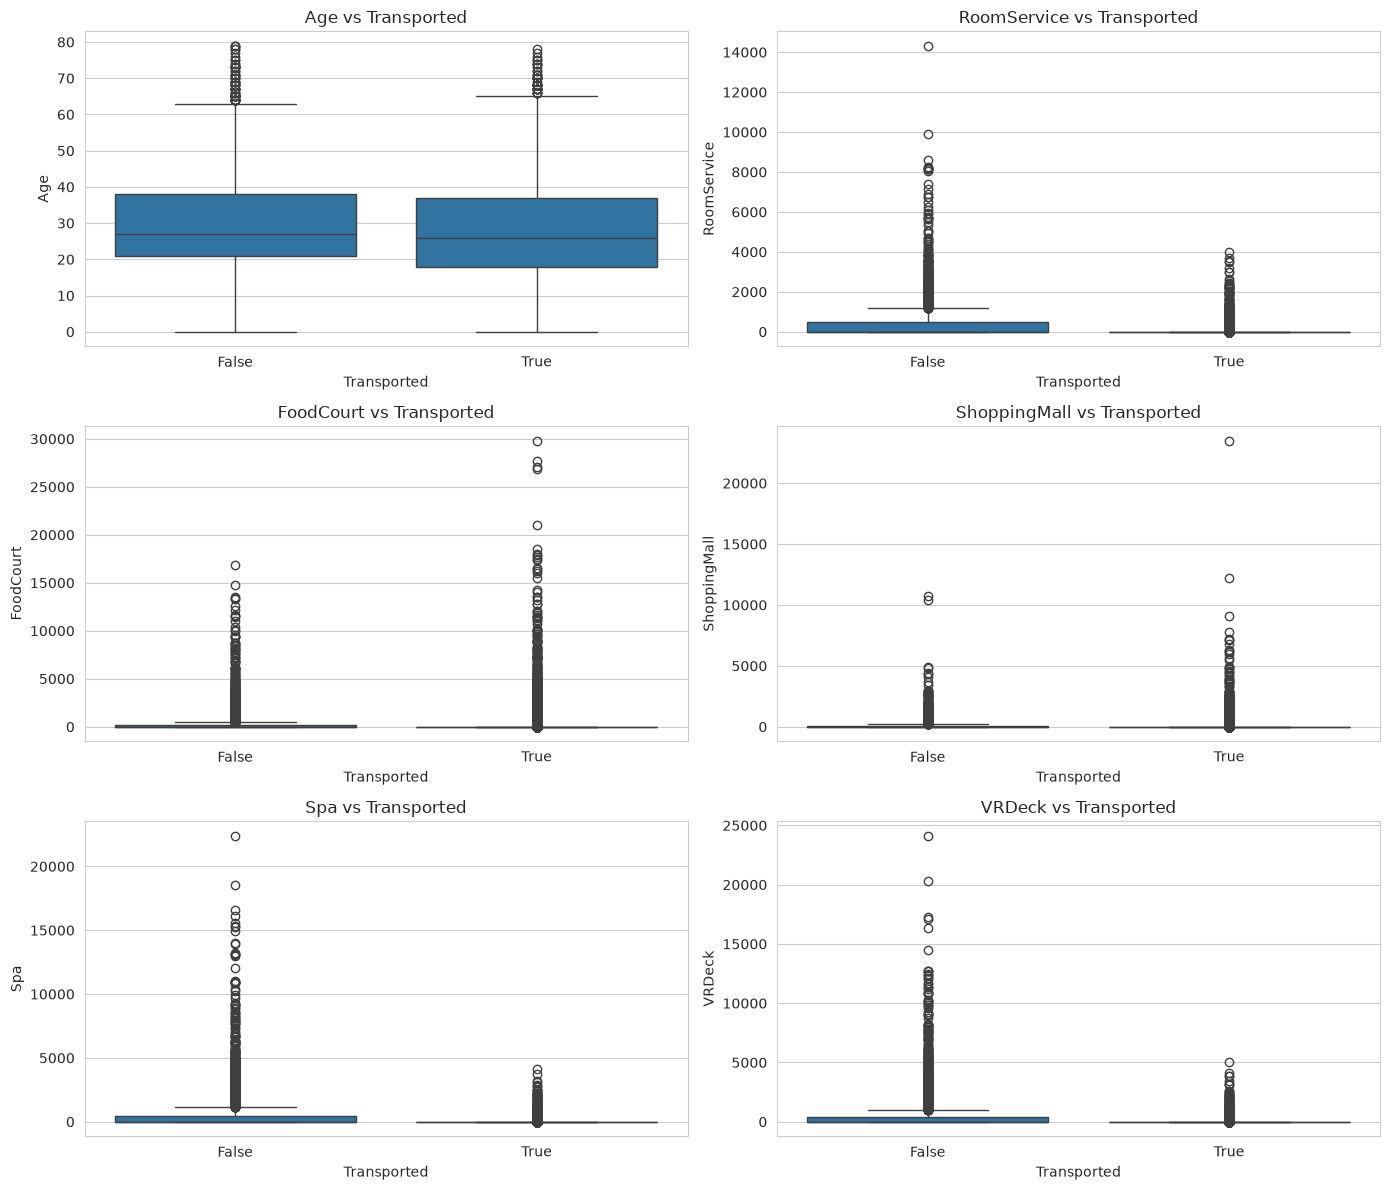

In [11]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df_clean,
        x='Transported',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Transported')

for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

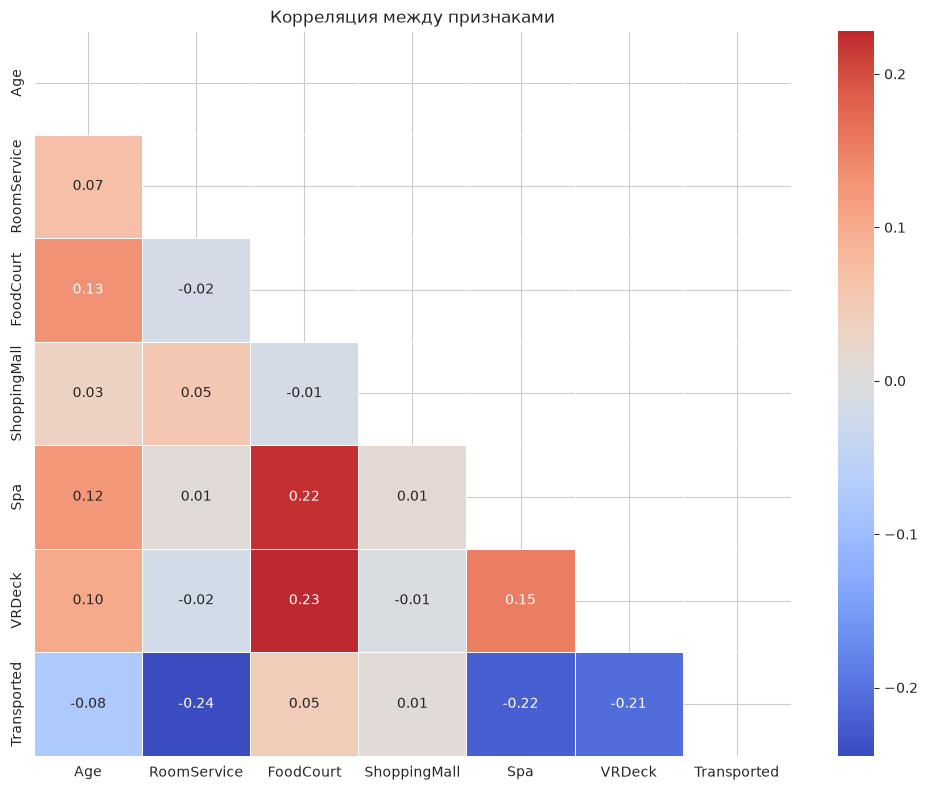

In [12]:
corr_df = df_clean[numeric_cols].copy()
corr_df['Transported'] = df_clean['Transported'].astype(int)

plt.figure(figsize=(10, 8))

corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

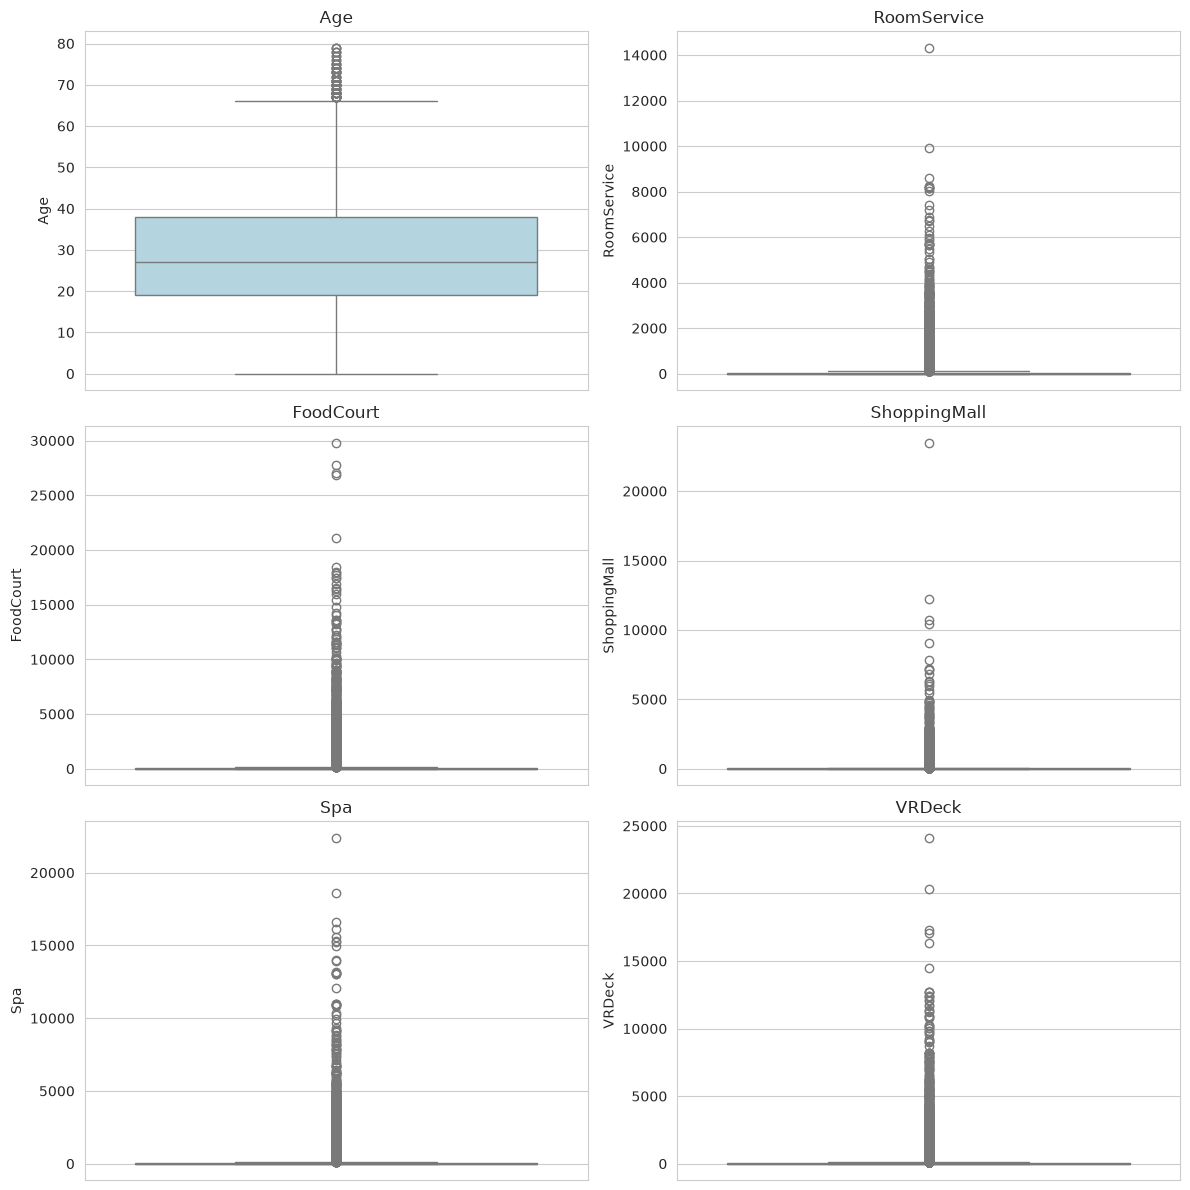

In [13]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df_clean[col],
        ax=axes[i],
        color='lightblue'
    )
    axes[i].set_title(col)

for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
cat_cols_for_analysis = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP'
]

for col in cat_cols_for_analysis:
    print(f'{col}')

    display(
        df_clean.groupby(col)['Transported']
        .agg(['count', 'mean'])
        .sort_values('mean', ascending=False)
    )

HomePlanet


,count,mean
HomePlanet,,
Europa,2131,0.658846
Mars,1759,0.523024
Earth,4602,0.423946


CryoSleep


,count,mean
CryoSleep,,
True,3037,0.817583
False,5439,0.328921


Destination


,count,mean
Destination,,
55 Cancri e,1800,0.610000
PSO J318.5-22,796,0.503769
TRAPPIST-1e,5915,0.471175


VIP


,count,mean
VIP,,
False,8291,0.506332
True,199,0.381910


# Работа с признаками, создание новых, удаление ненужных

In [15]:
cabin_parts = df_clean['Cabin'].str.split('/', expand=True)

df_clean['CabinDeck'] = cabin_parts[0]
df_clean['CabinNum'] = pd.to_numeric(cabin_parts[1], errors='coerce')
df_clean['CabinSide'] = cabin_parts[2]

In [16]:
columns_to_drop = ['PassengerId', 'Cabin', 'Name']

df_clean = df_clean.drop(columns=columns_to_drop)

In [17]:
df_clean.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,CabinDeck,CabinNum,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S


In [18]:
df_clean.isnull().sum()

HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
CabinDeck       199
CabinNum        199
CabinSide       199
dtype: int64

In [19]:
numeric_cols = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'CabinNum'
]

categorical_cols = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'CabinDeck',
    'CabinSide'
]

In [20]:
df_clean['Transported'].value_counts(normalize=True)

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

In [21]:
X = df_clean.drop(columns='Transported')
y = df_clean['Transported'].astype(int)

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

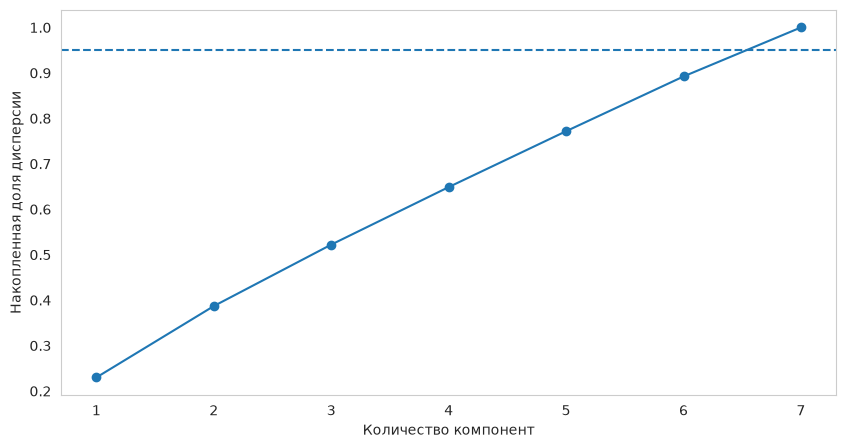

In [22]:
X_pca = X_dev[numeric_cols]

X_pca = SimpleImputer(strategy='median').fit_transform(X_pca)
X_pca = StandardScaler().fit_transform(X_pca)

pca = PCA()
pca.fit(X_pca)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(0.95, linestyle='--')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.grid()
plt.show()

# Обучение моделей

In [23]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

# LogReg

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=5000
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    logreg_pipeline,
    X_dev,
    y_dev,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print('LogisticRegression')
print('CV Accuracy:', scores.mean())
print('CV Accuracy std:', scores.std())

LogisticRegression
CV Accuracy: 0.7899053007773508
CV Accuracy std: 0.004477087958277419


# LogReg + L1 отбор признаков

In [25]:
from sklearn.model_selection import RandomizedSearchCV

inner_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

logreg_l1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        l1_ratio=1.0,
        solver='liblinear',
        max_iter=5000,
        random_state=42
    ))
])

logreg_l1_params = {
    'model__C': np.logspace(-3, 2, 30),
    'model__class_weight': [None, 'balanced'],
    'model__tol': [1e-4, 1e-3, 1e-2]
}

logreg_l1_search = RandomizedSearchCV(
    estimator=logreg_l1_pipeline,
    param_distributions=logreg_l1_params,
    n_iter=25,
    scoring='accuracy',
    cv=inner_cv,
    random_state=42,
    n_jobs=-1
)

logreg_l1_scores = cross_val_score(
    logreg_l1_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

logreg_l1_search.fit(X_dev, y_dev)

print('LogisticRegression L1')
print('CV Accuracy:', logreg_l1_scores.mean())
print('CV Accuracy std:', logreg_l1_scores.std())

LogisticRegression L1
CV Accuracy: 0.7900491856694372
CV Accuracy std: 0.0052905625550606185


# RF

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

rf_params = {
    'model__n_estimators': [100, 200, 300, 500, 700],
    'model__max_depth': [None, 5, 10, 15, 20, 30],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8],
    'model__bootstrap': [True, False],
    'model__class_weight': [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring='accuracy',
    cv=inner_cv,
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(
    rf_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

rf_search.fit(X_dev, y_dev)

print('RandomForestClassifier')
print('CV Accuracy:', rf_scores.mean())
print('CV Accuracy std:', rf_scores.std())

RandomForestClassifier
CV Accuracy: 0.8060116163000585
CV Accuracy std: 0.0027328955293659035


# Grad boosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

gb_params = {
    'model__n_estimators': [50, 100, 150, 200, 300],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__max_depth': [1, 2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__max_features': [None, 'sqrt', 'log2']
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=30,
    scoring='accuracy',
    cv=inner_cv,
    random_state=42,
    n_jobs=-1
)

gb_scores = cross_val_score(
    gb_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

gb_search.fit(X_dev, y_dev)

print('GradientBoostingClassifier')
print('CV Accuracy:', gb_scores.mean())
print('CV Accuracy std:', gb_scores.std())

GradientBoostingClassifier
CV Accuracy: 0.8032791480690358
CV Accuracy std: 0.007988929708921223


# CatBoost

In [28]:
from catboost import CatBoostClassifier

catboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', CatBoostClassifier(
        loss_function='Logloss',
        bootstrap_type='Bayesian',
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=1
    ))
])

catboost_params = {
    'model__iterations': [200, 300, 500, 700],
    'model__depth': [4, 5, 6, 7, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 7, 10],
    'model__random_strength': [0, 0.5, 1, 2],
    'model__bagging_temperature': [0, 0.5, 1, 2, 5]
}

catboost_search = RandomizedSearchCV(
    estimator=catboost_pipeline,
    param_distributions=catboost_params,
    n_iter=20,
    scoring='accuracy',
    cv=inner_cv,
    random_state=42,
    n_jobs=-1
)

catboost_scores = cross_val_score(
    catboost_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

catboost_search.fit(X_dev, y_dev)

print('CatBoostClassifier')
print('CV Accuracy:', catboost_scores.mean())
print('CV Accuracy std:', catboost_scores.std())

CatBoostClassifier
CV Accuracy: 0.8085998893193137
CV Accuracy std: 0.005031071011524211


# Blending

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

catboost_pred = cross_val_predict(
    catboost_search.best_estimator_,
    X_dev,
    y_dev,
    cv=cv,
    method='predict_proba',
    n_jobs=1
)[:, 1]

rf_pred = cross_val_predict(
    rf_search.best_estimator_,
    X_dev,
    y_dev,
    cv=cv,
    method='predict_proba',
    n_jobs=1
)[:, 1]

logreg_pred = cross_val_predict(
    logreg_l1_search.best_estimator_,
    X_dev,
    y_dev,
    cv=cv,
    method='predict_proba',
    n_jobs=1
)[:, 1]

blend_proba = (
    3 * catboost_pred
    + 2 * rf_pred
    + logreg_pred
) / 6

blend_pred = (blend_proba >= 0.5).astype(int)

blend_accuracy = accuracy_score(
    y_dev,
    blend_pred
)


print('Weighted Blending')
print('CV Accuracy:', blend_accuracy)
print('CV Accuracy std:', blend_accuracy.std())
print('Improvement:', blend_accuracy - catboost_scores.mean())

Weighted Blending
CV Accuracy: 0.8062985332182916
Improvement: -0.0023013561010221117


# Stacking

In [30]:
from sklearn.base import clone
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

catboost_best = clone(catboost_pipeline).set_params(
    **catboost_search.best_params_
)

rf_best = clone(rf_pipeline).set_params(
    **rf_search.best_params_
)

logreg_best = clone(logreg_l1_pipeline).set_params(
    **logreg_l1_search.best_params_
)

stacking_model = StackingClassifier(
    estimators=[
        ('catboost', catboost_best),
        ('random_forest', rf_best),
        ('logreg_l1', logreg_best)
    ],
    final_estimator=LogisticRegression(
        max_iter=5000
    ),
    stack_method='predict_proba',
    cv=inner_cv,
    n_jobs=-1
)

stacking_scores = cross_val_score(
    stacking_model,
    X_dev,
    y_dev,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

print('StackingClassifier')
print('CV Accuracy:', stacking_scores.mean())
print('CV Accuracy std:', stacking_scores.std())
print(
    'Improvement:',
    stacking_scores.mean() - catboost_scores.mean()
)

StackingClassifier
CV Accuracy: 0.8058665935691419
CV Accuracy std: 0.005103833787999678
Improvement: -0.0027332957501717825


# Финальное обучение + создание csv

In [33]:
from sklearn.base import clone

test = pd.read_csv('test.csv')
passenger_ids = test['PassengerId']

cabin_parts = test['Cabin'].str.split('/', expand=True)

test['CabinDeck'] = cabin_parts[0]
test['CabinNum'] = pd.to_numeric(cabin_parts[1], errors='coerce')
test['CabinSide'] = cabin_parts[2]

test = test.drop(columns=['PassengerId', 'Cabin', 'Name'])
test = test[X.columns]

final_model = clone(catboost_pipeline).set_params(
    **catboost_search.best_params_
)

final_model.fit(X, y)

predictions = final_model.predict(test).astype(bool)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Transported': predictions
})

submission.to_csv('submission.csv', index=False)

print(submission.head())
print(submission.shape)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
(4277, 2)
